<a href="https://colab.research.google.com/github/mann718/DL-lab/blob/main/lab%204/lab4_object_detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Preparation: Ground Truth Visualization

Selected image : banana_49.jpg
Image size     : 660 × 330
Bounding boxes : 1
  {'label': 'banana', 'xmin': 95, 'ymin': 63, 'xmax': 597, 'ymax': 266}


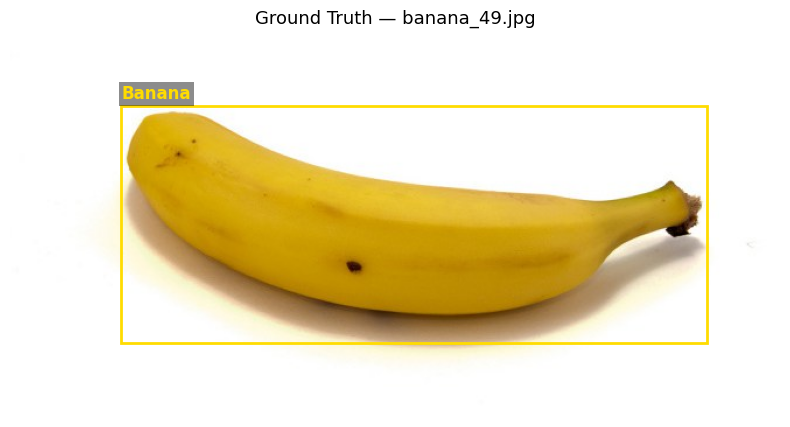

In [1]:
import os
import random
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

TRAIN_DIR = "/content/drive/MyDrive/lab4_obj_detection/dataset/fruits/train_zip/train"

CLASS_COLORS = {
    "apple":  "#FF4136",
    "banana": "#FFDC00",
    "orange": "#FF851B",
}

def parse_xml(xml_path):
    """Returns list of dicts: [{label, xmin, ymin, xmax, ymax}, ...]"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall("object"):
        label = obj.find("name").text.lower()
        bb    = obj.find("bndbox")
        boxes.append({
            "label": label,
            "xmin":  int(bb.find("xmin").text),
            "ymin":  int(bb.find("ymin").text),
            "xmax":  int(bb.find("xmax").text),
            "ymax":  int(bb.find("ymax").text),
        })
    return boxes

all_images = [
    f for f in os.listdir(TRAIN_DIR)
    if f.lower().endswith(".jpg")
    and os.path.exists(os.path.join(TRAIN_DIR, f.replace(".jpg", ".xml")))
]

img_file  = random.choice(all_images)
img_path  = os.path.join(TRAIN_DIR, img_file)
xml_path  = img_path.replace(".jpg", ".xml")

print(f"Selected image : {img_file}")

# Load image (BGR to RGB)
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w    = img_rgb.shape[:2]
print(f"Image size     : {w} × {h}")

boxes = parse_xml(xml_path)
print(f"Bounding boxes : {len(boxes)}")
for b in boxes:
    print(f"  {b}")

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
ax.imshow(img_rgb)

for b in boxes:
    color  = CLASS_COLORS.get(b["label"], "#FFFFFF")
    bw     = b["xmax"] - b["xmin"]
    bh     = b["ymax"] - b["ymin"]

    rect = patches.Rectangle(
        (b["xmin"], b["ymin"]), bw, bh,
        linewidth=2, edgecolor=color, facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(
        b["xmin"], b["ymin"] - 6,
        b["label"].capitalize(),
        color=color, fontsize=12, fontweight="bold",
        bbox=dict(facecolor="black", alpha=0.45, pad=2, edgecolor="none")
    )

ax.set_title(f"Ground Truth — {img_file}", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

### Task 1 - Core Concept: Intersection over Union (IoU)

                 IoU Demonstration                  

Case 1 — High Overlap
  Box 1 : [50, 50, 200, 200]
  Box 2 : [70, 70, 210, 210]
  IoU   : 0.6706

Case 2 — Partial Overlap
  Box 1 : [20, 20, 150, 150]
  Box 2 : [100, 100, 230, 230]
  IoU   : 0.0799

Case 3 — No Overlap (Disjoint)
  Box 1 : [10, 10, 80, 80]
  Box 2 : [150, 150, 250, 250]
  IoU   : 0.0000


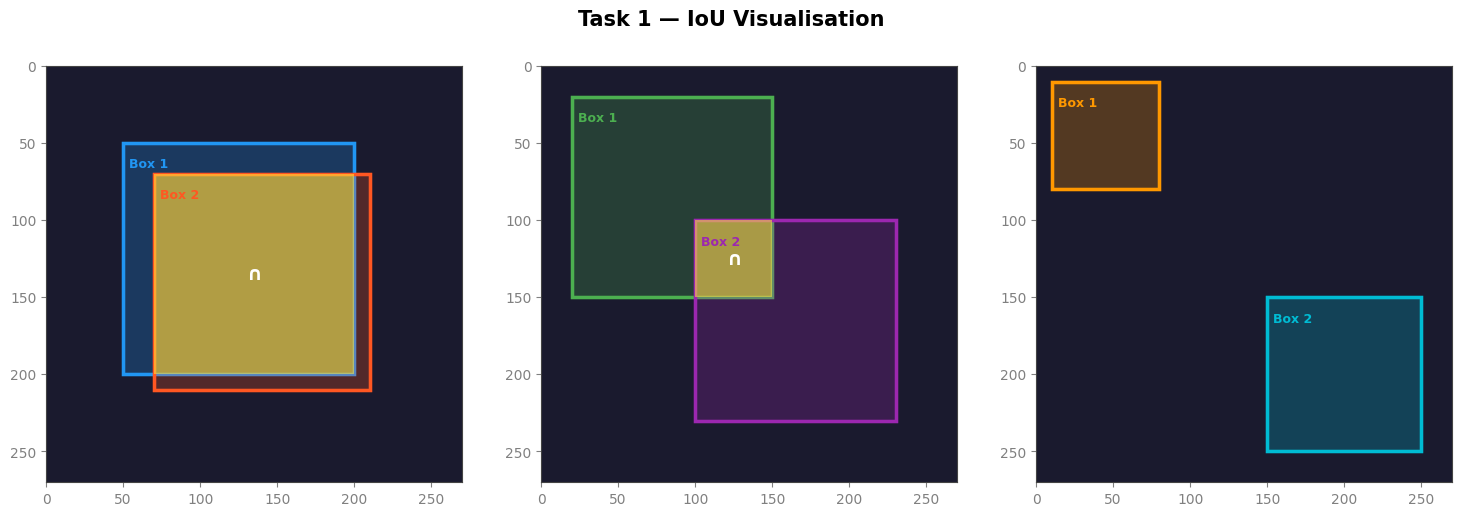

In [2]:
def compute_iou(box1, box2):
    """
    Parameters
    box1, box2 : list — [x_min, y_min, x_max, y_max]

    Returns
    float — IoU score in [0.0, 1.0]
    """
    inter_xmin = max(box1[0], box2[0])
    inter_ymin = max(box1[1], box2[1])
    inter_xmax = min(box1[2], box2[2])
    inter_ymax = min(box1[3], box2[3])

    inter_w = max(0, inter_xmax - inter_xmin)
    inter_h = max(0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = area_box1 + area_box2 - inter_area

    if union_area == 0:
        return 0.0

    return round(inter_area / union_area, 4)



test_cases = [
    {
        "label"  : "Case 1 — High Overlap",
        "box1"   : [50,  50, 200, 200],
        "box2"   : [70,  70, 210, 210],
        "color1" : "#2196F3",   # blue
        "color2" : "#FF5722",   # red-orange
    },
    {
        "label"  : "Case 2 — Partial Overlap",
        "box1"   : [20,  20, 150, 150],
        "box2"   : [100, 100, 230, 230],
        "color1" : "#4CAF50",   # green
        "color2" : "#9C27B0",   # purple
    },
    {
        "label"  : "Case 3 — No Overlap (Disjoint)",
        "box1"   : [10,  10,  80,  80],
        "box2"   : [150, 150, 250, 250],
        "color1" : "#FF9800",   # orange
        "color2" : "#00BCD4",   # cyan
    },
]

print("=" * 52)
print(f"{'IoU Demonstration':^52}")
print("=" * 52)

for case in test_cases:
    iou = compute_iou(case["box1"], case["box2"])
    print(f"\n{case['label']}")
    print(f"  Box 1 : {case['box1']}")
    print(f"  Box 2 : {case['box2']}")
    print(f"  IoU   : {iou:.4f}")



# Visualise all three cases
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Task 1 — IoU Visualisation", fontsize=15, fontweight="bold")

CANVAS = 270

for ax, case in zip(axes, test_cases):
    iou = compute_iou(case["box1"], case["box2"])

    ax.set_xlim(0, CANVAS)
    ax.set_ylim(CANVAS, 0)
    ax.set_facecolor("#1a1a2e")
    ax.set_aspect("equal")

    def draw_box(ax, box, color, label):
        x, y   = box[0], box[1]
        bw, bh = box[2] - box[0], box[3] - box[1]
        rect = patches.Rectangle(
            (x, y), bw, bh,
            linewidth=2.5, edgecolor=color,
            facecolor=color, alpha=0.25
        )
        ax.add_patch(rect)
        # Solid border on top
        rect_border = patches.Rectangle(
            (x, y), bw, bh,
            linewidth=2.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect_border)
        ax.text(x + 4, y + 16, label, color=color,
                fontsize=9, fontweight="bold")

    draw_box(ax, case["box1"], case["color1"], "Box 1")
    draw_box(ax, case["box2"], case["color2"], "Box 2")

    # Highlight intersection rectangle
    ix1 = max(case["box1"][0], case["box2"][0])
    iy1 = max(case["box1"][1], case["box2"][1])
    ix2 = min(case["box1"][2], case["box2"][2])
    iy2 = min(case["box1"][3], case["box2"][3])
    if ix2 > ix1 and iy2 > iy1:
        inter_patch = patches.Rectangle(
            (ix1, iy1), ix2 - ix1, iy2 - iy1,
            linewidth=0, facecolor="#FFEB3B", alpha=0.55
        )
        ax.add_patch(inter_patch)
        ax.text((ix1 + ix2) / 2, (iy1 + iy2) / 2,
                "∩", color="white", fontsize=14,
                ha="center", va="center", fontweight="bold")

    ax.set_title(f"{case['label']}\nIoU = {iou:.4f}", fontsize=10,
                 color="white", pad=8)
    ax.tick_params(colors="gray")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

plt.tight_layout()
plt.show()

### Task 2 - The Baseline: Selective Search (R-CNN Step 1)

In [3]:
import cv2
import random
import os

Image       : apple_46.jpg
Total proposals generated : 4561
Using first : 200


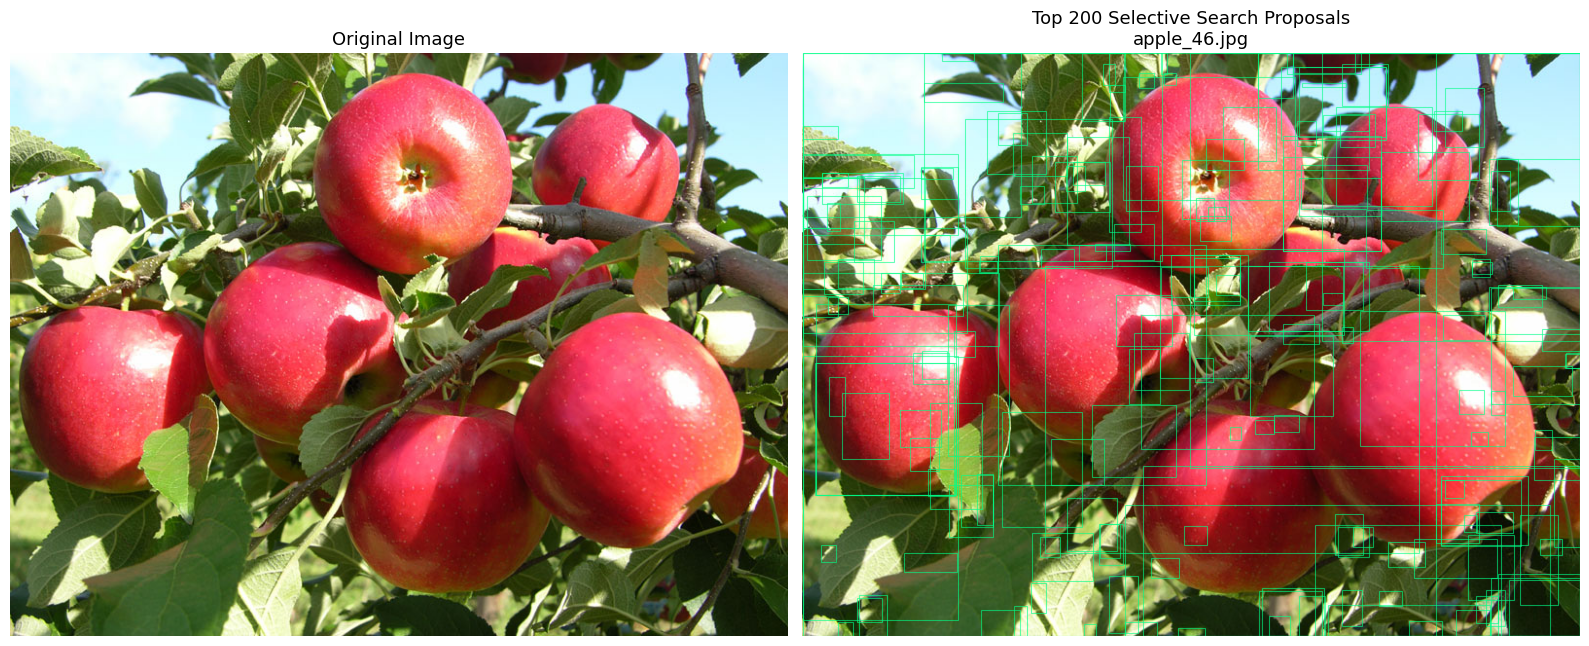

In [4]:
all_images = [f for f in os.listdir(TRAIN_DIR) if f.lower().endswith(".jpg")]
img_file = random.choice(all_images)
img_path = os.path.join(TRAIN_DIR, img_file)

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img_bgr)
ss.switchToSelectiveSearchFast()
proposals = ss.process()

top200 = proposals[:200]
print(f"Image       : {img_file}")
print(f"Total proposals generated : {len(proposals)}")
print(f"Using first : {len(top200)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img_rgb)
for (x, y, w, h) in top200:
    rect = patches.Rectangle((x, y), w, h,
                              linewidth=0.8, edgecolor="#00FF88", facecolor="none", alpha=0.6)
    axes[1].add_patch(rect)

axes[1].set_title(f"Top 200 Selective Search Proposals\n{img_file}", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Task 3 - Implementing the R-CNN Bottleneck.

In [5]:
# loading pre-tained resnet model
import torch
import torchvision.models as models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1])  # remove final FC
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("ResNet18 loaded — final FC layer removed")
print(f"Output: 512-dim feature vector per crop")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]


ResNet18 loaded — final FC layer removed
Output: 512-dim feature vector per crop


In [6]:
# Prepare image tensor and top-100 proposals
import torchvision.transforms as T

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
])

top100 = top200[:100]  # top200 from Task 2
img_h, img_w = img_rgb.shape[:2]

print(f"Image shape  : {img_rgb.shape}")
print(f"Proposals    : {len(top100)}")

Image shape  : (600, 800, 3)
Proposals    : 100


In [7]:
import time

features_rcnn = []
skipped = 0

start = time.time()

with torch.no_grad():
    for (x, y, w, h) in top100:
        # clamp box to image boundaries
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(img_w, x + w), min(img_h, y + h)

        if x2 <= x1 or y2 <= y1:
            skipped += 1
            continue

        crop = img_rgb[y1:y2, x1:x2]          # crop from numpy image
        tensor = transform(crop).unsqueeze(0).to(device)  # (1, 3, 224, 224)
        feat = feature_extractor(tensor)       # (1, 512, 1, 1)
        features_rcnn.append(feat.squeeze().cpu())

end = time.time()
rcnn_time = end - start

print("=" * 45)
print(f"  R-CNN Bottleneck — Timing Results")
print("=" * 45)
print(f"  Crops processed : {len(features_rcnn)}")
print(f"  Crops skipped   : {skipped}  (invalid bbox)")
print(f"  Total time      : {rcnn_time:.4f} seconds")
print(f"  Avg per crop    : {rcnn_time/len(features_rcnn)*1000:.2f} ms")
print("=" * 45)
print(f"\n  Feature tensor shape (last crop): {features_rcnn[-1].shape}")

  R-CNN Bottleneck — Timing Results
  Crops processed : 100
  Crops skipped   : 0  (invalid bbox)
  Total time      : 1.4790 seconds
  Avg per crop    : 14.79 ms

  Feature tensor shape (last crop): torch.Size([512])


### Task 4 - Implementing Fast R-CNN (RoI Pooling)

In [8]:
full_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
])

# strip avgpool + fc → keep only conv layers
conv_backbone = nn.Sequential(*list(resnet18.children())[:-2]).to(device)
conv_backbone.eval()

img_tensor = full_transform(img_rgb).unsqueeze(0).to(device)  # (1,3,H,W)

with torch.no_grad():
    feature_map = conv_backbone(img_tensor)  # (1, 512, H/32, W/32)

_, C, fH, fW = feature_map.shape
_, _, iH, iW = img_tensor.shape

print(f"Input image size    : {iW} x {iH}")
print(f"Feature map size    : {fW} x {fH}  (channels: {C})")
print(f"Spatial stride      : {iW//fW}  (1/{iW//fW})")

Input image size    : 800 x 600
Feature map size    : 25 x 19  (channels: 512)
Spatial stride      : 32  (1/32)


In [9]:
# torchvision roi_pool expects boxes as (N,5): [batch_idx, x1, y1, x2, y2]
boxes_xyxy = []
for (x, y, w, h) in top100:
    x1, y1 = max(0, x), max(0, y)
    x2, y2 = min(img_w, x + w), min(img_h, y + h)
    if x2 > x1 and y2 > y1:
        boxes_xyxy.append([0, x1, y1, x2, y2])  # batch_idx = 0

roi_tensor = torch.tensor(boxes_xyxy, dtype=torch.float32).to(device)
print(f"Valid RoI boxes : {len(roi_tensor)}")
print(f"Tensor shape    : {roi_tensor.shape}  — [batch_idx, x1, y1, x2, y2]")

Valid RoI boxes : 100
Tensor shape    : torch.Size([100, 5])  — [batch_idx, x1, y1, x2, y2]


In [10]:
import time
from torchvision.ops import roi_pool

spatial_scale = 1 / 32.0
output_size   = (7, 7)

start = time.time()

with torch.no_grad():
    feature_map = conv_backbone(img_tensor)                  # 1 CNN pass
    pooled = roi_pool(feature_map, roi_tensor,               # 1 RoI pool
                      output_size=output_size,
                      spatial_scale=spatial_scale)

end = time.time()
fast_rcnn_time = end - start

print("=" * 45)
print(f"  Fast R-CNN — Timing Results")
print("=" * 45)
print(f"  RoIs processed  : {len(roi_tensor)}")
print(f"  Total time      : {fast_rcnn_time:.4f} seconds")
print(f"  Avg per RoI     : {fast_rcnn_time/len(roi_tensor)*1000:.2f} ms")
print("=" * 45)
print(f"\n  Pooled output shape : {pooled.shape}")  # (N, 512, 7, 7)

  Fast R-CNN — Timing Results
  RoIs processed  : 100
  Total time      : 0.0212 seconds
  Avg per RoI     : 0.21 ms

  Pooled output shape : torch.Size([100, 512, 7, 7])


In [11]:
speedup = rcnn_time / fast_rcnn_time

print("=" * 45)
print(f"  R-CNN  vs  Fast R-CNN  —  Comparison")
print("=" * 45)
print(f"  R-CNN  total time : {rcnn_time:.4f}s")
print(f"  Fast R-CNN time   : {fast_rcnn_time:.4f}s")
print(f"  Speedup           : {speedup:.1f}x faster")
print("=" * 45)

  R-CNN  vs  Fast R-CNN  —  Comparison
  R-CNN  total time : 1.4790s
  Fast R-CNN time   : 0.0212s
  Speedup           : 69.9x faster


## Conceptual Analysis: Why is Fast R-CNN so much faster?

In R-CNN approach, the CNN runs independently for every single region
proposal. For 100 proposals 100 full forward passes through all
convolutional layers — repeating enormous amounts of overlapping computation because
most proposals share large portions of the same image area.

Fast R-CNN eliminates this redundancy in one move, here the entire image is passed through the convolutional exactly once,
producing a shared feature map. All 100 region proposals then simply
*sample* their features from this single map via RoI Pooling, a cheap
spatial-cropping operation saving the hustle of re-running the convolutions.

So it eliminates:
- Repeated convolution across shared pixel regions.
- Repeated batch-norm and activation computations over the same spatial areas.
- Repeated image resize + normalize preprocessing per crop.

Fast R-CNN is ~70× faster here because convolution cost drops
from O(N × image) to O(1 × image) + O(N × pool).

### Task 5 - Faster R-CNN

In [12]:
import torchvision.models.detection as detection

faster_rcnn = detection.fasterrcnn_resnet50_fpn(weights=detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
faster_rcnn = faster_rcnn.to(device)
faster_rcnn.eval()

print("Faster R-CNN (ResNet50 + FPN) loaded")
print(f"Running on: {device}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 170MB/s]


Faster R-CNN (ResNet50 + FPN) loaded
Running on: cuda


In [13]:
import torchvision.transforms.functional as TF

# COCO class labels (91 classes)
COCO_LABELS = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A',
    'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
    'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

img_t = TF.to_tensor(img_rgb).to(device)

with torch.no_grad():
    predictions = faster_rcnn([img_t])

boxes  = predictions[0]['boxes'].cpu()
labels = predictions[0]['labels'].cpu()
scores = predictions[0]['scores'].cpu()

print(f"Total raw predictions : {len(boxes)}")
print(f"Score range           : {scores.min():.3f} → {scores.max():.3f}")

Total raw predictions : 28
Score range           : 0.057 → 0.990


In [14]:
def filter_predictions(boxes, labels, scores, threshold=0.80):
    mask = scores >= threshold
    return boxes[mask], labels[mask], scores[mask]

f_boxes, f_labels, f_scores = filter_predictions(boxes, labels, scores, threshold=0.80)

print(f"Predictions after 0.80 threshold : {len(f_boxes)}")
for i, (lbl, scr) in enumerate(zip(f_labels, f_scores)):
    label_name = COCO_LABELS[lbl.item()] if lbl.item() < len(COCO_LABELS) else str(lbl.item())
    print(f"  [{i+1}] {label_name:<20} confidence: {scr:.4f}")

Predictions after 0.80 threshold : 6
  [1] apple                confidence: 0.9904
  [2] apple                confidence: 0.9841
  [3] apple                confidence: 0.9753
  [4] apple                confidence: 0.9680
  [5] apple                confidence: 0.9676
  [6] apple                confidence: 0.9537


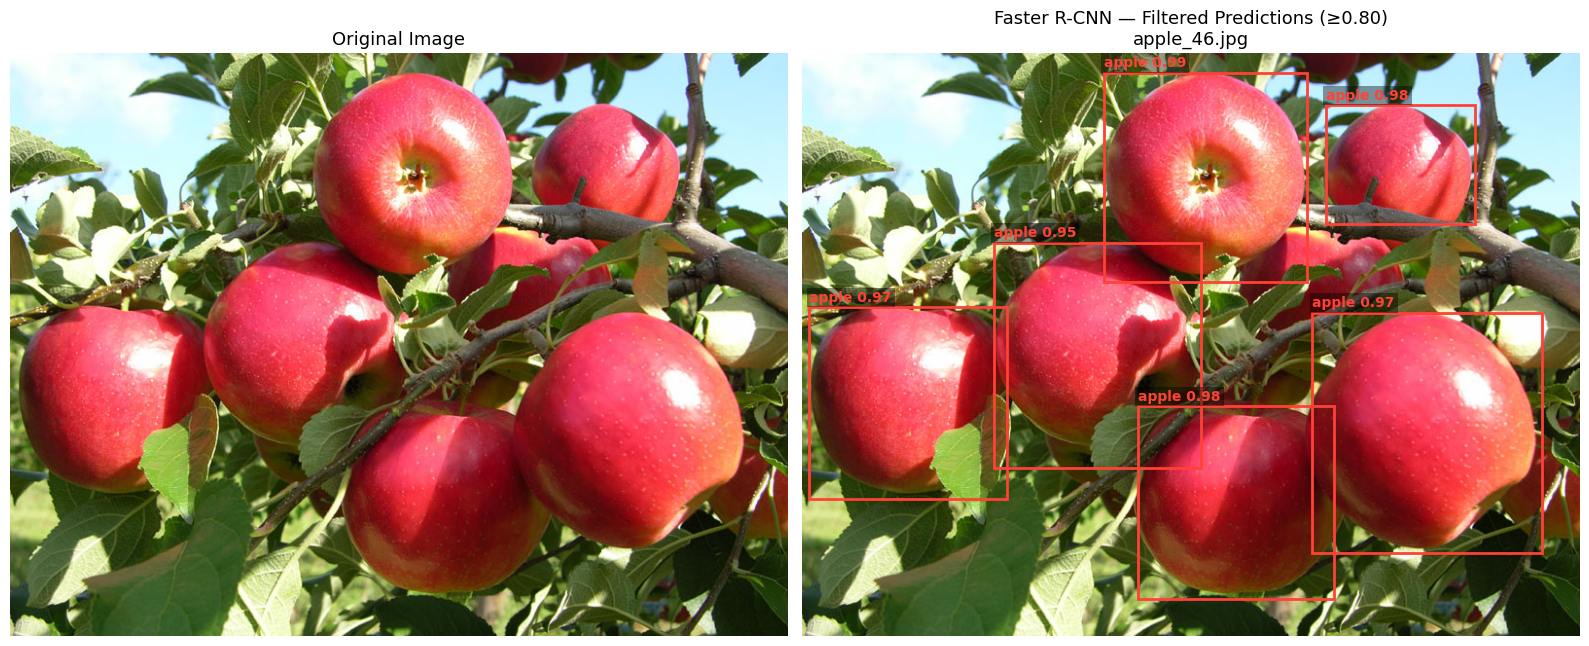

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

LABEL_COLORS = {
    "apple"  : "#FF4136",
    "banana" : "#FFDC00",
    "orange" : "#FF851B",
}
DEFAULT_COLOR = "#00E5FF"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img_rgb)

for box, lbl, scr in zip(f_boxes, f_labels, f_scores):
    x1, y1, x2, y2 = box.tolist()
    label_name = COCO_LABELS[lbl.item()] if lbl.item() < len(COCO_LABELS) else str(lbl.item())
    color = LABEL_COLORS.get(label_name.lower(), DEFAULT_COLOR)

    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor=color, facecolor="none")
    axes[1].add_patch(rect)
    axes[1].text(x1, y1 - 6, f"{label_name} {scr:.2f}",
                 color=color, fontsize=10, fontweight="bold",
                 bbox=dict(facecolor="black", alpha=0.4, pad=2, edgecolor="none"))

axes[1].set_title(f"Faster R-CNN — Filtered Predictions (≥0.80)\n{img_file}", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Conceptual Analysis: How does the RPN replace Selective Search?

Selective Search is a hand-crafted, CPU-based algorithm that groups pixels using
low-level cues like colour, texture, and region size. It runs independent of the
network, has no learnable parameters, and cannot improve with training data.

Region Proposal Network (RPN) replaces it with a small, fully
convolutional network that shares the same backbone feature map already computed
for detection. At every spatial location on the feature map the RPN places a set
of anchor boxes (multiple scales and aspect ratios) and predicts following things:

1. **Objectness score** — is there any object inside this anchor?
2. **Box regression offsets** — how should this anchor be adjusted to tighten
   around the object?

This eliminates Selective Search because:

- **End-to-end learning**: the RPN is trained jointly with the detector, so it
  learns exactly what makes a good proposal for the target domain rather than
  relying on generic image statistics.
- **Shared computation**: the RPN reuses the backbone feature map at zero extra
  CNN cost — Selective Search paid a full separate CPU pass.
- **Speed**: generating ~300 high-quality proposals via the RPN takes only a few
  milliseconds on a GPU; Selective Search typically needs 1–2 seconds on CPU.

### Task 6 - Non-Maximum Suppression (NMS)

In [16]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    boxes         : list of [x_min, y_min, x_max, y_max]
    scores        : list of float confidence scores
    iou_threshold : float

    Returns indices of kept boxes.
    """
    if len(boxes) == 0:
        return []

    # sort by score descending
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)

    kept = []

    while order:
        current = order[0]
        kept.append(current)
        order = order[1:]  # remove selected

        remaining = []
        for idx in order:
            iou = compute_iou(boxes[current], boxes[idx])  # from Task 1
            if iou <= iou_threshold:
                remaining.append(idx)  # keep only non-overlapping
        order = remaining

    return kept

In [17]:
import numpy as np

# Simulate 8 noisy detections around 2 real objects
demo_boxes = [
    # cluster 1 — apple on the left (ground truth ~[30,30,130,130])
    [30,  30,  130, 130],
    [35,  28,  135, 132],
    [25,  32,  128, 128],
    [40,  40,  138, 138],
    # cluster 2 — orange on the right (ground truth ~[180,50,280,150])
    [180, 50,  280, 150],
    [185, 48,  282, 152],
    [178, 55,  275, 148],
    [190, 60,  285, 155],
]

demo_scores = [0.95, 0.88, 0.76, 0.61, 0.92, 0.84, 0.70, 0.55]

print("Input boxes and scores:")
for i, (b, s) in enumerate(zip(demo_boxes, demo_scores)):
    print(f"  [{i}] score={s:.2f}  box={b}")

Input boxes and scores:
  [0] score=0.95  box=[30, 30, 130, 130]
  [1] score=0.88  box=[35, 28, 135, 132]
  [2] score=0.76  box=[25, 32, 128, 128]
  [3] score=0.61  box=[40, 40, 138, 138]
  [4] score=0.92  box=[180, 50, 280, 150]
  [5] score=0.84  box=[185, 48, 282, 152]
  [6] score=0.70  box=[178, 55, 275, 148]
  [7] score=0.55  box=[190, 60, 285, 155]


In [18]:
for thresh in [0.1, 0.5, 0.9]:
    kept_idx = nms(demo_boxes, demo_scores, iou_threshold=thresh)
    print(f"\nIoU threshold = {thresh}")
    print(f"  Kept {len(kept_idx)}/{len(demo_boxes)} boxes → indices {kept_idx}")
    for i in kept_idx:
        print(f"    [{i}] score={demo_scores[i]:.2f}  box={demo_boxes[i]}")


IoU threshold = 0.1
  Kept 2/8 boxes → indices [0, 4]
    [0] score=0.95  box=[30, 30, 130, 130]
    [4] score=0.92  box=[180, 50, 280, 150]

IoU threshold = 0.5
  Kept 2/8 boxes → indices [0, 4]
    [0] score=0.95  box=[30, 30, 130, 130]
    [4] score=0.92  box=[180, 50, 280, 150]

IoU threshold = 0.9
  Kept 8/8 boxes → indices [0, 4, 1, 5, 2, 6, 3, 7]
    [0] score=0.95  box=[30, 30, 130, 130]
    [4] score=0.92  box=[180, 50, 280, 150]
    [1] score=0.88  box=[35, 28, 135, 132]
    [5] score=0.84  box=[185, 48, 282, 152]
    [2] score=0.76  box=[25, 32, 128, 128]
    [6] score=0.70  box=[178, 55, 275, 148]
    [3] score=0.61  box=[40, 40, 138, 138]
    [7] score=0.55  box=[190, 60, 285, 155]


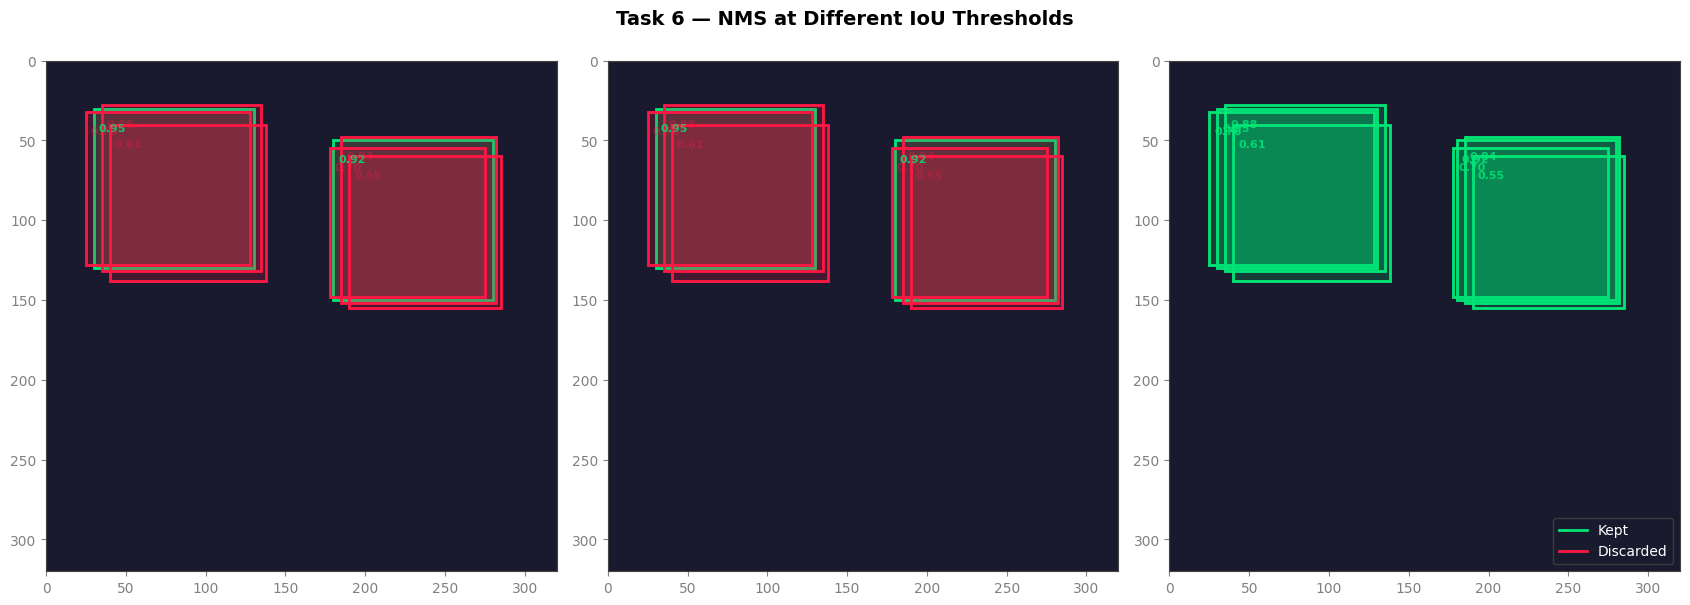

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CANVAS = 320
thresholds = [0.1, 0.5, 0.9]
colors_all  = ["#888888"] * len(demo_boxes)
color_kept  = "#00E676"
color_disc  = "#FF1744"

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Task 6 — NMS at Different IoU Thresholds", fontsize=14, fontweight="bold")

for ax, thresh in zip(axes, thresholds):
    kept_idx = set(nms(demo_boxes, demo_scores, iou_threshold=thresh))

    ax.set_xlim(0, CANVAS)
    ax.set_ylim(CANVAS, 0)
    ax.set_facecolor("#1a1a2e")
    ax.set_aspect("equal")

    for i, (box, score) in enumerate(zip(demo_boxes, demo_scores)):
        x1, y1, x2, y2 = box
        color = color_kept if i in kept_idx else color_disc
        alpha = 0.85 if i in kept_idx else 0.35

        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color,
                                  facecolor=color, alpha=0.18)
        ax.add_patch(rect)
        border = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                    linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(border)
        ax.text(x1+3, y1+14, f"{score:.2f}",
                color=color, fontsize=8, fontweight="bold", alpha=alpha)

    kept_n = len(kept_idx)
    ax.set_title(f"Threshold = {thresh}\nKept: {kept_n} / {len(demo_boxes)} boxes",
                 fontsize=11, color="white", pad=8)

    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    ax.tick_params(colors="gray")

# legend
from matplotlib.lines import Line2D
legend = [Line2D([0],[0], color=color_kept, lw=2, label="Kept"),
          Line2D([0],[0], color=color_disc,  lw=2, label="Discarded")]
axes[2].legend(handles=legend, loc="lower right",
               facecolor="#1a1a2e", edgecolor="#444", labelcolor="white")

plt.tight_layout()
plt.show()

## Conceptual Analysis: IoU Threshold as a "Strictness Dial"

### High threshold (IoU = 0.9) : Too lenient at discarding
A box must overlap by 90 % with the selected box before it gets discarded.
For tightly packed objects like a basket of apples, neighbouring apples naturally
have moderate overlap (~0.3–0.6 IoU) simply due to proximity, well below 0.9.
So almost no box gets suppressed. The result is a flood of duplicate
detections around every single apple, making the output cluttered and unusable.

### Low threshold (IoU = 0.1) : Too aggressive at discarding
Any box that overlaps even slightly (10 %) gets thrown away. For tightly packed
objects, the bounding box of one apple may already overlap a neighbouring apple's
box by more than 0.1 IoU just because they are touching. NMS then incorrectly
suppresses the second apple's box entirely. The result is under-detection,
the model appears to see only one or two apples in a pile of ten.

### The right middle ground (~0.4–0.6)
A threshold around 0.5 keeps one tight box per object while correctly suppressing
near-duplicate boxes for the *same* object, giving clean, one-box-per-fruit
predictions even in a crowded scene.

### Task 7 - YOLO Fine-Tuning

In [20]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.1 MB/s eta 0:00:00


In [21]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

CLASS_MAP = {"apple": 0, "banana": 1, "orange": 2}

def convert_xml_to_yolo(img_path, xml_path, out_txt_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img = Image.open(img_path)
    iw, ih = img.size

    # fallback if XML size is 0
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)
    if w == 0 or h == 0:
        w, h = iw, ih

    lines = []
    for obj in root.findall("object"):
        label = obj.find("name").text.lower().strip()
        if label not in CLASS_MAP:
            continue
        cls_id = CLASS_MAP[label]
        bb = obj.find("bndbox")
        xmin = float(bb.find("xmin").text)
        ymin = float(bb.find("ymin").text)
        xmax = float(bb.find("xmax").text)
        ymax = float(bb.find("ymax").text)

        xc = ((xmin + xmax) / 2) / w
        yc = ((ymin + ymax) / 2) / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h
        lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    with open(out_txt_path, "w") as f:
        f.write("\n".join(lines))

TRAIN_DIR = "/content/drive/MyDrive/lab4_obj_detection/dataset/fruits/train_zip/train"
TEST_DIR  = "/content/drive/MyDrive/lab4_obj_detection/dataset/fruits/test_zip/test"

for split_dir in [TRAIN_DIR, TEST_DIR]:
    converted = 0
    for fname in os.listdir(split_dir):
        if not fname.lower().endswith(".jpg"):
            continue
        xml_path = os.path.join(split_dir, fname.replace(".jpg", ".xml"))
        txt_path = os.path.join(split_dir, fname.replace(".jpg", ".txt"))
        if os.path.exists(xml_path):
            convert_xml_to_yolo(os.path.join(split_dir, fname), xml_path, txt_path)
            converted += 1
    print(f"{split_dir.split('/')[-1]} — converted {converted} annotations")

train — converted 240 annotations
test — converted 60 annotations


In [22]:
yaml_content = f"""
path: /content/fruits_yolo
train: train/images
val: test/images

nc: 3
names: ['apple', 'banana', 'orange']
"""

os.makedirs("/content/fruits_yolo/train/images", exist_ok=True)
os.makedirs("/content/fruits_yolo/train/labels", exist_ok=True)
os.makedirs("/content/fruits_yolo/test/images",  exist_ok=True)
os.makedirs("/content/fruits_yolo/test/labels",  exist_ok=True)

with open("/content/fruits_yolo/fruits.yaml", "w") as f:
    f.write(yaml_content)

print("YAML written to /content/fruits_yolo/fruits.yaml")

YAML written to /content/fruits_yolo/fruits.yaml


In [23]:
import shutil

def populate_yolo_split(src_dir, img_dst, lbl_dst):
    copied = 0
    for fname in os.listdir(src_dir):
        src = os.path.join(src_dir, fname)
        if fname.lower().endswith(".jpg"):
            shutil.copy2(src, os.path.join(img_dst, fname))
            copied += 1
        elif fname.lower().endswith(".txt"):
            shutil.copy2(src, os.path.join(lbl_dst, fname))
    print(f"  {img_dst.split('/')[-2]}/{img_dst.split('/')[-1]} — {copied} images copied")

populate_yolo_split(TRAIN_DIR,
                    "/content/fruits_yolo/train/images",
                    "/content/fruits_yolo/train/labels")

populate_yolo_split(TEST_DIR,
                    "/content/fruits_yolo/test/images",
                    "/content/fruits_yolo/test/labels")

  train/images — 240 images copied
  test/images — 60 images copied


In [24]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data    = "/content/fruits_yolo/fruits.yaml",
    epochs  = 15,
    imgsz   = 640,
    batch   = 16,
    name    = "fruits_yolov8n",
    project = "/content/yolo_runs",
    device  = 0,          # T4 GPU
    verbose = True,
)

print("Training complete")
print(f"Best weights: /content/yolo_runs/fruits_yolov8n/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fruits_yolo/fruits.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

In [25]:
fine_tuned_model = YOLO("/content/yolo_runs/fruits_yolov8n/weights/best.pt")

metrics = fine_tuned_model.val(
    data   = "/content/fruits_yolo/fruits.yaml",
    split  = "val",
    device = 0,
)

map50    = metrics.box.map50
map5095  = metrics.box.map
precision = metrics.box.mp
recall    = metrics.box.mr

print("=" * 40)
print("  YOLOv8n Fine-tuned — Test Metrics")
print("=" * 40)
print(f"  mAP@50       : {map50:.4f}")
print(f"  mAP@50-95    : {map5095:.4f}")
print(f"  Precision    : {precision:.4f}")
print(f"  Recall       : {recall:.4f}")
print("=" * 40)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 906.1±603.6 MB/s, size: 42.7 KB)
val: Scanning /content/fruits_yolo/test/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 18.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.1s
                   all         60        117      0.897      0.881       0.94      0.692
                 apple         24         35       0.87      0.971      0.982      0.807
                banana         22         40      0.894      0.839       0.88      0.554
                orange         22         42      0.927      0.833       0.96      0.713
Speed: 6.9ms preprocess, 20.3ms inference, 0.0ms loss, 5.6ms postprocess per image
Results saved to /content/runs/detect/val
  YOLOv8n Fine-t

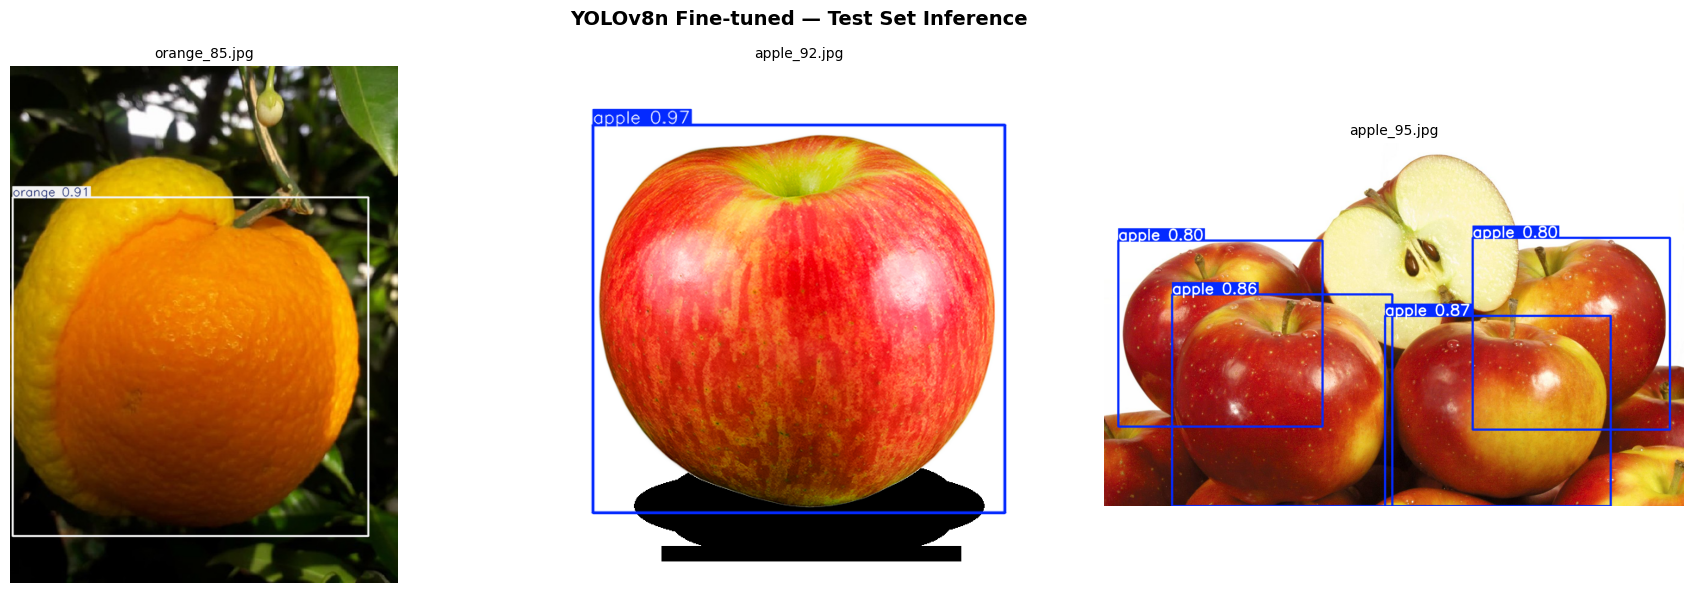

In [26]:
import random, cv2
import matplotlib.pyplot as plt

test_imgs = [
    f for f in os.listdir("/content/fruits_yolo/test/images")
    if f.lower().endswith(".jpg")
]
random.seed(21)
sample_3 = random.sample(test_imgs, 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("YOLOv8n Fine-tuned — Test Set Inference", fontsize=14, fontweight="bold")

for ax, fname in zip(axes, sample_3):
    img_path = f"/content/fruits_yolo/test/images/{fname}"
    preds    = fine_tuned_model(img_path, verbose=False)[0]

    # ultralytics plot() returns BGR numpy array
    annotated = preds.plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    ax.imshow(annotated_rgb)
    ax.set_title(fname, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [28]:
import torch
import torchvision.transforms.functional as TF
from torchvision.ops import box_iou
import os, time
import numpy as np
import xml.etree.ElementTree as ET
from PIL import Image

# Faster R-CNN COCO label → our class index
COCO_TO_LOCAL = {"apple": 0, "banana": 1, "orange": 2}
LOCAL_COCO_IDS = {53: 0, 52: 1, 55: 2}  # COCO ids: banana=52,apple=53,orange=55 (0-indexed label tensor)

def parse_gt(xml_path, img_path):
    """Returns gt_boxes (N,4) and gt_labels (N,) as tensors."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    img  = Image.open(img_path)
    iw, ih = img.size
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)
    if w == 0 or h == 0:
        w, h = iw, ih

    boxes, labels = [], []
    for obj in root.findall("object"):
        label = obj.find("name").text.lower().strip()
        if label not in CLASS_MAP:
            continue
        bb = obj.find("bndbox")
        boxes.append([float(bb.find("xmin").text), float(bb.find("ymin").text),
                       float(bb.find("xmax").text), float(bb.find("ymax").text)])
        labels.append(CLASS_MAP[label])
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels)


def eval_detector(pred_fn, test_img_dir, iou_thresh=0.5, score_thresh=0.5):
    """
    pred_fn(img_path) → (boxes tensor (N,4), labels tensor (N,), scores tensor (N,))
    Returns precision, recall, avg inference time (ms).
    """
    tp = fp = fn = 0
    times = []

    img_files = [f for f in os.listdir(test_img_dir) if f.lower().endswith(".jpg")]

    for fname in img_files:
        img_path = os.path.join(test_img_dir, fname)
        xml_path = img_path.replace(".jpg", ".xml")
        if not os.path.exists(xml_path):
            continue

        gt_boxes, gt_labels = parse_gt(xml_path, img_path)
        if len(gt_boxes) == 0:
            continue

        t0 = time.time()
        pred_boxes, pred_labels, pred_scores = pred_fn(img_path)
        times.append((time.time() - t0) * 1000)

        # filter by score threshold
        if len(pred_scores) > 0:
            mask = pred_scores >= score_thresh
            pred_boxes  = pred_boxes[mask]
            pred_labels = pred_labels[mask]

        if len(pred_boxes) == 0:
            fn += len(gt_boxes)
            continue

        # match predictions to GT via IoU
        iou_matrix = box_iou(pred_boxes, gt_boxes)   # (P, G)
        matched_gt = set()

        for p_idx in range(len(pred_boxes)):
            best_iou, best_g = iou_matrix[p_idx].max(0)
            best_g = best_g.item()
            if (best_iou >= iou_thresh
                    and best_g not in matched_gt
                    and pred_labels[p_idx].item() == gt_labels[best_g].item()):
                tp += 1
                matched_gt.add(best_g)
            else:
                fp += 1

        fn += len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall, float(np.mean(times))


TEST_IMG_DIR = "/content/fruits_yolo/test/images"
print("Evaluation framework ready.")

Evaluation framework ready.


In [30]:
test_files = [f for f in os.listdir(TEST_IMG_DIR) if f.lower().endswith(".jpg")][:3]

for fname in test_files:
    img_path = os.path.join(TEST_IMG_DIR, fname)
    img = Image.open(img_path).convert("RGB")
    t   = TF.to_tensor(img).to(device)
    with torch.no_grad():
        out = faster_rcnn([t])[0]

    print(f"\n{fname}")
    print(f"  Total predictions: {len(out['boxes'])}")
    top = out['scores'].argsort(descending=True)[:5]
    for i in top:
        lbl = out['labels'][i].item()
        scr = out['scores'][i].item()
        name = COCO_LABELS[lbl] if lbl < len(COCO_LABELS) else f"id={lbl}"
        print(f"  label_id={lbl:3d}  name={name:<20} score={scr:.3f}")


apple_78.jpg
  Total predictions: 5
  label_id= 53  name=apple                score=0.992
  label_id= 53  name=apple                score=0.204
  label_id= 53  name=apple                score=0.175
  label_id= 55  name=orange               score=0.071
  label_id= 16  name=bird                 score=0.066

apple_89.jpg
  Total predictions: 10
  label_id= 53  name=apple                score=0.992
  label_id= 53  name=apple                score=0.585
  label_id= 53  name=apple                score=0.559
  label_id= 53  name=apple                score=0.201
  label_id= 55  name=orange               score=0.113

orange_82.jpg
  Total predictions: 11
  label_id= 55  name=orange               score=0.981
  label_id= 55  name=orange               score=0.979
  label_id= 55  name=orange               score=0.931
  label_id= 55  name=orange               score=0.927
  label_id= 55  name=orange               score=0.627


In [31]:
test_files = os.listdir(TEST_IMG_DIR)
jpgs = [f for f in test_files if f.lower().endswith(".jpg")]
xmls = [f for f in test_files if f.lower().endswith(".xml")]
txts = [f for f in test_files if f.lower().endswith(".txt")]

print(f"Total files : {len(test_files)}")
print(f"JPGs        : {len(jpgs)}")
print(f"XMLs        : {len(xmls)}")
print(f"TXTs        : {len(txts)}")
print(f"\nSample JPGs : {jpgs[:3]}")
print(f"Sample XMLs : {xmls[:3]}")

# check if xml exists for first jpg
if jpgs:
    sample_jpg = jpgs[0]
    expected_xml = os.path.join(TEST_IMG_DIR, sample_jpg.replace(".jpg", ".xml"))
    print(f"\nLooking for : {expected_xml}")
    print(f"Exists      : {os.path.exists(expected_xml)}")

# check original test dir
print(f"\nOriginal TEST_DIR files (first 5):")
orig = os.listdir(TEST_DIR)
print([f for f in orig[:5]])

Total files : 60
JPGs        : 60
XMLs        : 0
TXTs        : 0

Sample JPGs : ['apple_78.jpg', 'apple_89.jpg', 'orange_82.jpg']
Sample XMLs : []

Looking for : /content/fruits_yolo/test/images/apple_78.xml
Exists      : False

Original TEST_DIR files (first 5):
['apple_82.jpg', 'apple_81.jpg', 'apple_83.xml', 'apple_77.xml', 'apple_81.xml']


In [32]:
import shutil

copied = 0
for fname in os.listdir(TEST_DIR):
    if fname.lower().endswith(".xml"):
        shutil.copy2(os.path.join(TEST_DIR, fname),
                     os.path.join(TEST_IMG_DIR, fname))
        copied += 1

print(f"Copied {copied} XML files to {TEST_IMG_DIR}")

# verify
xmls_now = [f for f in os.listdir(TEST_IMG_DIR) if f.lower().endswith(".xml")]
print(f"XMLs now in test/images: {len(xmls_now)}")

Copied 60 XML files to /content/fruits_yolo/test/images
XMLs now in test/images: 60


In [33]:
converted = 0
for fname in os.listdir(TEST_IMG_DIR):
    if not fname.lower().endswith(".jpg"):
        continue
    xml_path = os.path.join(TEST_IMG_DIR, fname.replace(".jpg", ".xml"))
    txt_path = os.path.join("/content/fruits_yolo/test/labels",
                             fname.replace(".jpg", ".txt"))
    if os.path.exists(xml_path) and not os.path.exists(txt_path):
        convert_xml_to_yolo(os.path.join(TEST_IMG_DIR, fname), xml_path, txt_path)
        converted += 1

print(f"Converted {converted} XMLs → YOLO TXT labels")

Converted 0 XMLs → YOLO TXT labels


In [34]:
def frcnn_pred_fn(img_path):
    img = Image.open(img_path).convert("RGB")
    t   = TF.to_tensor(img).to(device)
    with torch.no_grad():
        out = faster_rcnn([t])[0]
    boxes  = out["boxes"].cpu()
    labels = out["labels"].cpu()
    scores = out["scores"].cpu()

    # remap COCO label ids to our 3-class ids; drop everything else
    keep_b, keep_l, keep_s = [], [], []
    for b, l, s in zip(boxes, labels, scores):
        l_item = l.item()
        if l_item in LOCAL_COCO_IDS:
            keep_b.append(b)
            keep_l.append(torch.tensor(LOCAL_COCO_IDS[l_item]))
            keep_s.append(s)

    if len(keep_b) == 0:
        return torch.zeros((0,4)), torch.zeros(0,dtype=torch.long), torch.zeros(0)
    return torch.stack(keep_b), torch.stack(keep_l), torch.stack(keep_s)


print("Evaluating Faster R-CNN on test set (this may take ~1–2 min)...")
frcnn_p, frcnn_r, frcnn_ms = eval_detector(frcnn_pred_fn, TEST_IMG_DIR,
                                             iou_thresh=0.5, score_thresh=0.5)
print(f"  Precision : {frcnn_p:.4f}")
print(f"  Recall    : {frcnn_r:.4f}")
print(f"  Avg time  : {frcnn_ms:.1f} ms/image")

Evaluating Faster R-CNN on test set (this may take ~1–2 min)...
  Precision : 0.4558
  Recall    : 0.8376
  Avg time  : 128.1 ms/image


In [35]:
yolo_pretrained = YOLO("yolov8n.pt")

# YOLOv8 COCO class ids for our fruits
YOLO_COCO_MAP = {47: 0, 46: 1, 49: 2}   # apple=47, banana=46, orange=49

def yolo_pre_pred_fn(img_path):
    preds = yolo_pretrained(img_path, verbose=False)[0]
    boxes, labels, scores = [], [], []
    for box in preds.boxes:
        cid = int(box.cls.item())
        if cid in YOLO_COCO_MAP:
            boxes.append(box.xyxy[0].cpu())
            labels.append(torch.tensor(YOLO_COCO_MAP[cid]))
            scores.append(box.conf[0].cpu())
    if len(boxes) == 0:
        return torch.zeros((0,4)), torch.zeros(0,dtype=torch.long), torch.zeros(0)
    return torch.stack(boxes), torch.stack(labels), torch.stack(scores)


print("Evaluating YOLOv8n pretrained on test set...")
yp_p, yp_r, yp_ms = eval_detector(yolo_pre_pred_fn, TEST_IMG_DIR,
                                    iou_thresh=0.5, score_thresh=0.25)
print(f"  Precision : {yp_p:.4f}")
print(f"  Recall    : {yp_r:.4f}")
print(f"  Avg time  : {yp_ms:.1f} ms/image")

Evaluating YOLOv8n pretrained on test set...
  Precision : 0.5472
  Recall    : 0.7436
  Avg time  : 26.1 ms/image


In [45]:
def yolo_ft_pred_fn(img_path):
    preds = fine_tuned_model(img_path, verbose=False)[0]
    boxes, labels, scores = [], [], []
    for box in preds.boxes:
        boxes.append(box.xyxy[0].cpu())
        labels.append(box.cls[0].cpu().long())
        scores.append(box.conf[0].cpu())
    if len(boxes) == 0:
        return torch.zeros((0,4)), torch.zeros(0,dtype=torch.long), torch.zeros(0)
    return torch.stack(boxes), torch.stack(labels), torch.stack(scores)


print("Evaluating YOLOv8n fine-tuned on test set...")
yft_p, yft_r, yft_ms = eval_detector(yolo_ft_pred_fn, TEST_IMG_DIR,
                                       iou_thresh=0.5, score_thresh=0.25)
print(f"  Precision : {yft_p:.4f}")
print(f"  Recall    : {yft_r:.4f}")
print(f"  Avg time  : {yft_ms:.1f} ms/image")

Evaluating YOLOv8n fine-tuned on test set...
  Precision : 0.8134
  Recall    : 0.9316
  Avg time  : 17.9 ms/image


In [46]:
rows = [
    ("Faster R-CNN (pretrained)",  frcnn_ms, frcnn_p, frcnn_r),
    ("YOLOv8n (pretrained)",       yp_ms,    yp_p,    yp_r),
    ("YOLOv8n (fine-tuned)",       yft_ms,   yft_p,   yft_r),
]

sep = "-" * 68
hdr = f"{'Model':<30} {'Inf. Time (ms)':>15} {'Precision':>12} {'Recall':>10}"

print(sep)
print(hdr)
print(sep)
for name, ms, p, r in rows:
    print(f"{name:<30} {ms:>15.1f} {p:>12.4f} {r:>10.4f}")
print(sep)
print(f"\nmAP@50     (fine-tuned YOLO) : {map50:.4f}")
print(f"mAP@50-95  (fine-tuned YOLO) : {map5095:.4f}")

--------------------------------------------------------------------
Model                           Inf. Time (ms)    Precision     Recall
--------------------------------------------------------------------
Faster R-CNN (pretrained)                128.1       0.4558     0.8376
YOLOv8n (pretrained)                      26.1       0.5472     0.7436
YOLOv8n (fine-tuned)                      17.9       0.8134     0.9316
--------------------------------------------------------------------

mAP@50     (fine-tuned YOLO) : 0.9403
mAP@50-95  (fine-tuned YOLO) : 0.6917
